# LogiCheck: Comprehensive Exploratory Data Analysis

this notebook provides a deep dive into the logical fallacy dataset. we explore label distributions, co-occurrence patterns, lexical characteristics, and data quality across all splits.

In [1]:
import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

# add project root to path
sys.path.append(os.path.abspath("."))
from src.data import load_all_datasets

# download nltk data
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

# set aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.family"] = "sans-serif"
PRIMARY_COLOR = "#615fff"
SECONDARY_COLOR = "#1d293d"

c:\Users\Anand\anaconda3\envs\nlp-gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading & Quality Check

we load the consolidated dataset and check for missing values or duplicates.

In [2]:
data_dir = "data/raw/"
df = load_all_datasets(data_dir)
print(f"total samples: {len(df):,}")

# check for missing values
missing = df.isnull().sum()
print("\nmissing values:")
print(missing)

# check for duplicates
duplicates = df.duplicated(subset=['text']).sum()
print(f"\nduplicate texts: {duplicates}")

df.head()

total samples: 7,706

missing values:
text       0
context    0
labels     0
source     0
dtype: int64

duplicate texts: 4


,text,context,labels,source
0,Lack of transparency in government isn't unexp...,"<div class=""entry"">\n<p><i><span style=""font-w...",[no_fallacy],train
1,While the issues discussed here should be addr...,"<div class=""entry"">\n<p><i><span style=""font-w...",[appeal_to_authority],train
2,The excuse that Brazilian municipalities do no...,"<div class=""entry"">\n<p><i><span style=""font-w...",[no_fallacy],train
3,This is what's to be expected of developing an...,"<div class=""entry"">\n<p><i><span style=""font-w...",[no_fallacy],train
4,"Sad to say, I have to agree with you. Rulers c...","<div class=""entry"">\n<p><i><span style=""font-w...",[appeal_to_tradition],train


## 2. Label Analysis

### 2.1 Distribution Across Splits
ensuring that fallacy categories are represented consistently in train, dev, and test sets.

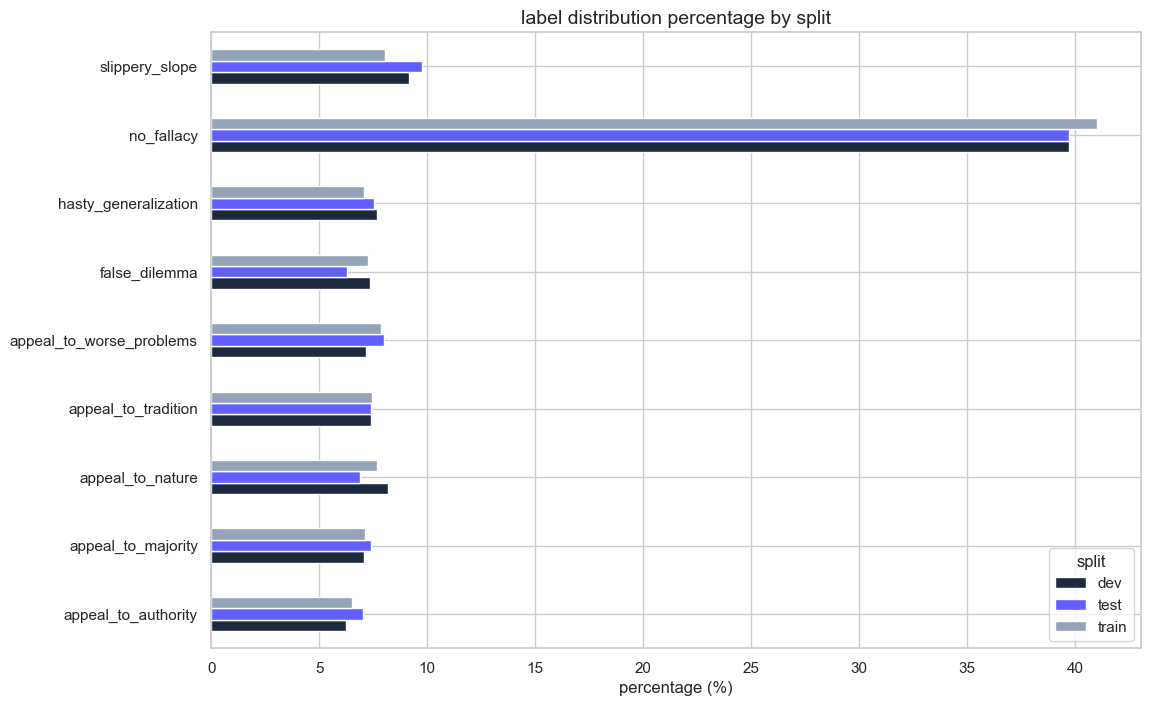

In [3]:
exploded = df.explode("labels")
split_dist = pd.crosstab(exploded['labels'], exploded['source'], normalize='columns') * 100

split_dist.plot(kind='barh', figsize=(12, 8), color=[SECONDARY_COLOR, PRIMARY_COLOR, "#94a3b8"])
plt.title("label distribution percentage by split", fontsize=14)
plt.xlabel("percentage (%)")
plt.ylabel("")
plt.legend(title="split")
plt.show()

### 2.2 Label Co-occurrence
as this is a multi-label task, we check which fallacies frequently appear together.

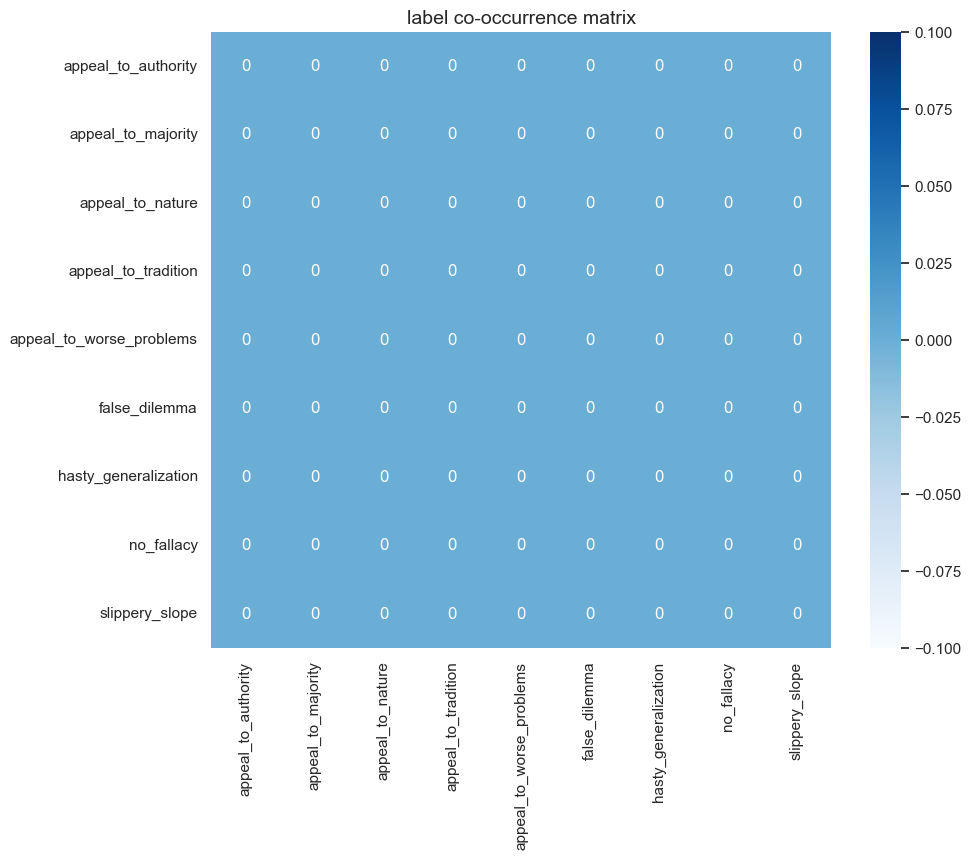

In [4]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
label_data = mlb.fit_transform(df['labels'])
label_df = pd.DataFrame(label_data, columns=mlb.classes_)

co_occurrence = label_df.T.dot(label_df)
np.fill_diagonal(co_occurrence.values, 0)

plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="Blues")
plt.title("label co-occurrence matrix", fontsize=14)
plt.show()

## 3. Text & Lexical Analysis

### 3.1 Sequence Lengths
understanding word and character counts.

C:\Users\Anand\AppData\Local\Temp\ipykernel_5756\813597761.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="word_count", y="source", palette="muted")


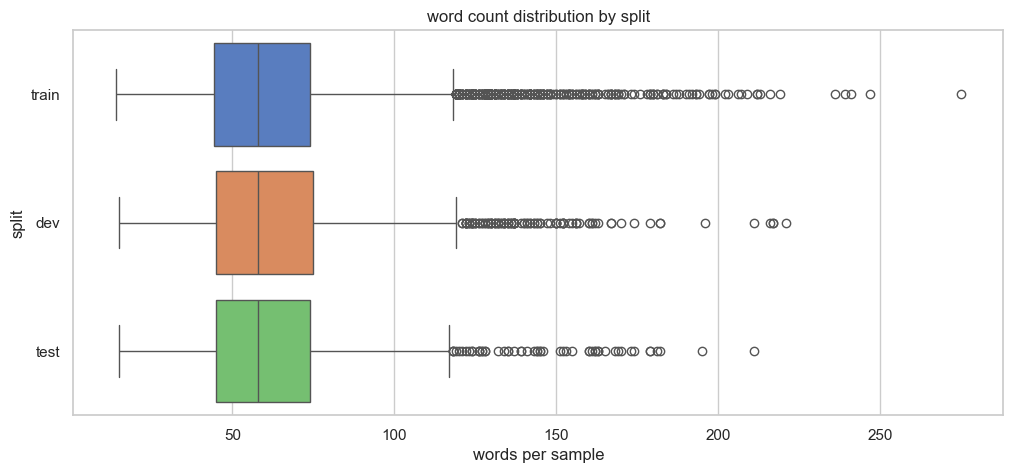

word count statistics:
         count       mean        std   min    25%   50%   75%    max
source                                                              
dev     1538.0  63.639142  30.781585  15.0  45.00  58.0  75.0  221.0
test     798.0  63.726817  30.819067  15.0  45.00  58.0  74.0  211.0
train   5370.0  63.570950  30.701616  14.0  44.25  58.0  74.0  275.0


In [5]:
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="word_count", y="source", palette="muted")
plt.title("word count distribution by split")
plt.xlabel("words per sample")
plt.ylabel("split")
plt.show()

print("word count statistics:")
print(df.groupby('source')['word_count'].describe())

### 3.2 Top N-grams by Fallacy
identifying common phrases associated with specific fallacies.

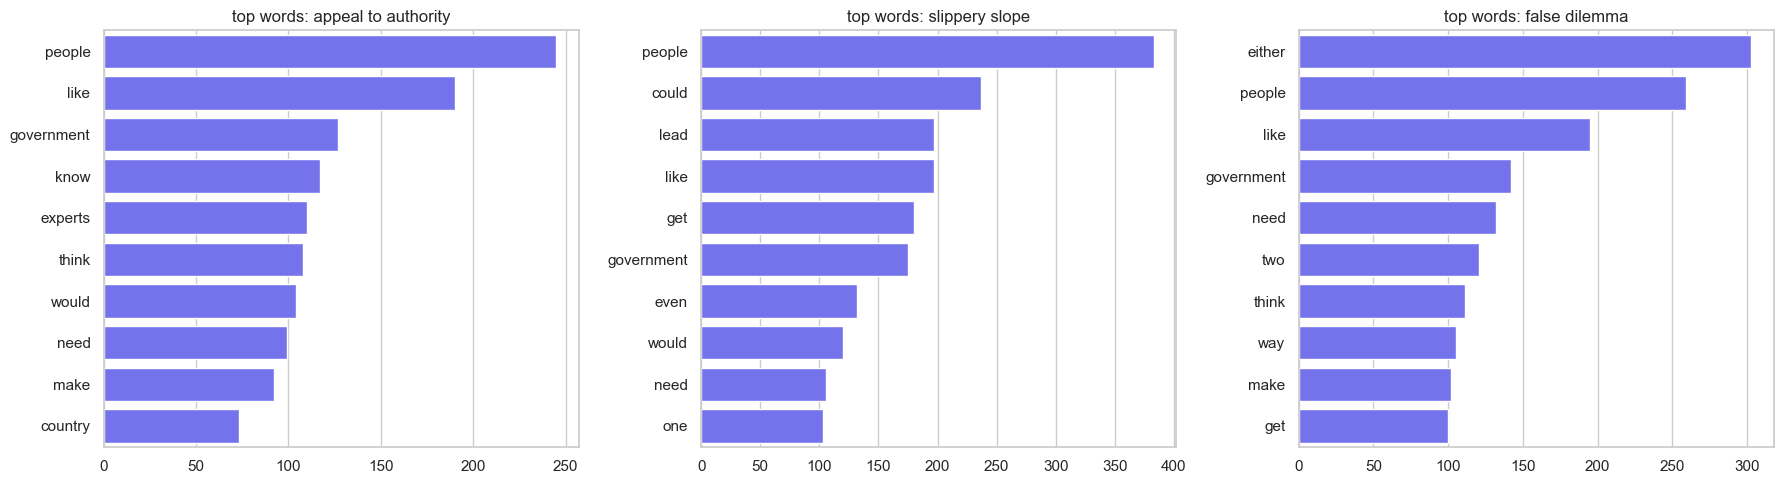

In [6]:
def get_top_ngrams(corpus, n=1, top_k=10):
    words = [w.lower() for text in corpus for w in str(text).split() if w.lower() not in stop_words and w.isalnum()]
    if n > 1:
        # simple bigram logic
        words = [f"{words[i]} {words[i+1]}" for i in range(len(words)-1)]
    return Counter(words).most_common(top_k)

target_fallacies = ["appeal_to_authority", "slippery_slope", "false_dilemma"]

fig, axes = plt.subplots(1, len(target_fallacies), figsize=(18, 5))
for i, fallacy in enumerate(target_fallacies):
    subset = df[df['labels'].apply(lambda x: fallacy in x)]['text']
    top_words = get_top_ngrams(subset, n=1)

    words, counts = zip(*top_words) if top_words else ([], [])
    sns.barplot(x=list(counts), y=list(words), ax=axes[i], color=PRIMARY_COLOR)
    axes[i].set_title(f"top words: {fallacy.replace('_', ' ')}")

plt.tight_layout()
plt.show()

### 3.3 Word Cloud
a visual overview of the entire corpus.

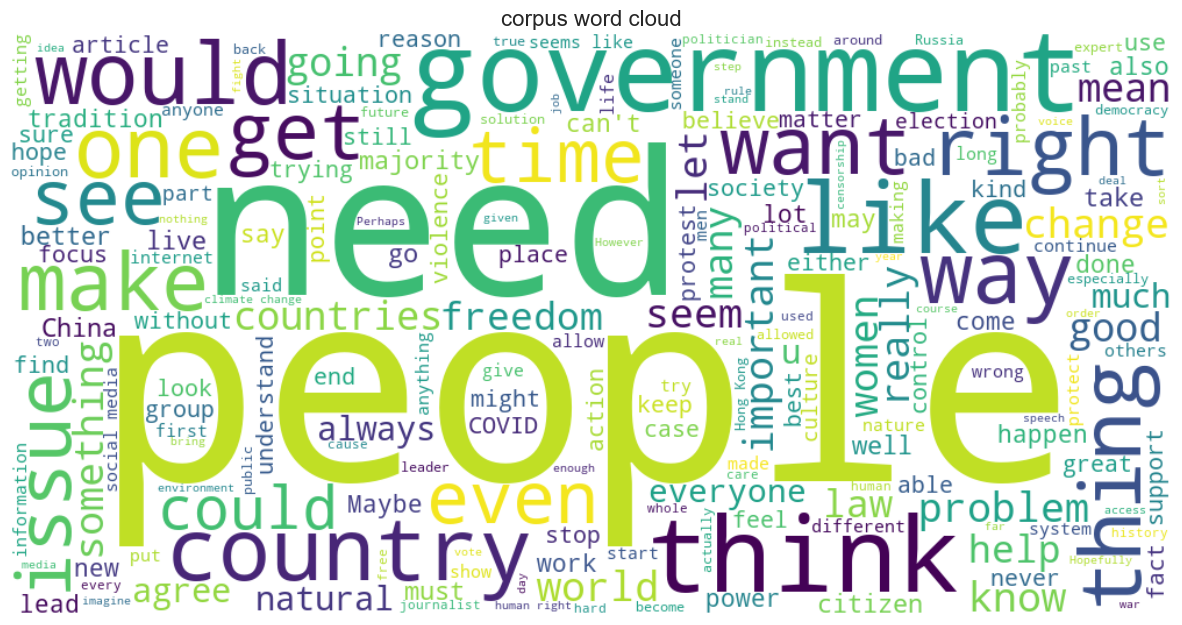

In [7]:
all_text = " ".join(df['text'].values)
wordcloud = WordCloud(width=1000, height=500, background_color='white',
                      colormap='viridis', stopwords=stop_words).generate(all_text)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("corpus word cloud", fontsize=16)
plt.show()

## 4. Multi-Label Complexity

visualizing how many labels each sample has.

C:\Users\Anand\AppData\Local\Temp\ipykernel_5756\1992985894.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="num_labels", palette="magma")


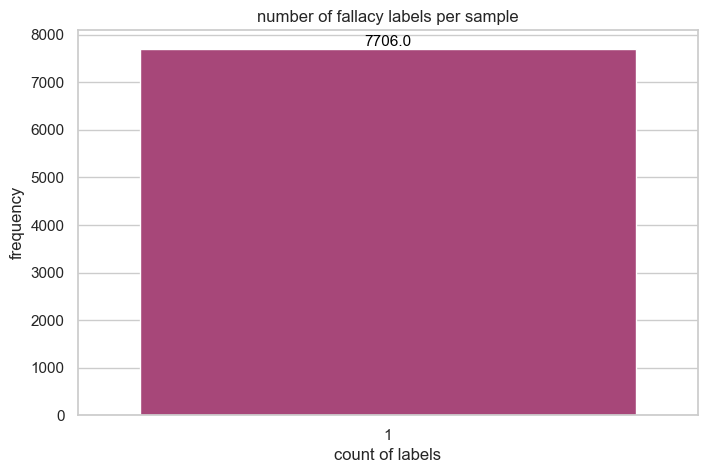

In [8]:
df["num_labels"] = df["labels"].apply(len)
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="num_labels", palette="magma")
plt.title("number of fallacy labels per sample")
plt.xlabel("count of labels")
plt.ylabel("frequency")

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

## 5. Sample Inspection with Context

exploring how text and context (if available) relate.

In [ ]:
has_context = df[df['context'].notna() & (df['context'] != 'None')]
if not has_context.empty:
    print(f"samples with context: {len(has_context)}")
    for i, (_, row) in enumerate(has_context.sample(min(2, len(has_context))).iterrows()):
        print(f"\n--- sample {i+1} ---")
        print(f"labels : {row['labels']}")
        print(f"context: {row['context'][:150]}...")
        print(f"text   : {row['text']}")
else:
    print("no context data found in this dataset.")

samples with context: 7706

--- sample 1 ---
labels : ['appeal_to_nature']
context: <div class="entry">
<p>Bangladesh has been rocked with student protests across the country after an undergraduate of the country's prestigious Banglad...
text   : People will naturally protest injustice. The students have every reason to. The death of their fellow student is major.

--- sample 2 ---
labels : ['no_fallacy']
context: <div class="entry">
<p>Investigative journalist <a href="https://twitter.com/fisayosoyombo">‘Fisayo Soyombo</a> is at risk of arrest for an undercover...
text   : Nigerian people deserve honesty, and truth and their Justice system. So the Exposé by Fisayo Soyambo was long overdue. They should not be trying to detain him. They should be trying to work with him and the people to improve conditions.


: 